# MNIST Digit Classifier — CNN

A Convolutional Neural Network trained on MNIST, built to directly compare against the ANN baseline from `01-ann-mnist-digit-classifier`. The core question: how much does exploiting 2D spatial structure actually matter for image classification?

**Spoiler:** ANN peaked at 97.86%. CNN hits **99.14%** — because convolutional layers learn *where* patterns are in an image, not just *whether* they exist.

**Dataset:** 60,000 training + 10,000 test images, 28×28 grayscale digits (0–9)  
**Baseline to beat:** 97.86% (ANN with hidden layer, `01-ann-mnist-digit-classifier`)

## 1. Setup & Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.21.0


## 2. Load & Preprocess Data

One key difference from the ANN notebook: we keep images as 2D (28×28) instead of flattening to 784. CNNs need the spatial structure intact — that's the whole point.

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to 0-1
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Reshape to (samples, height, width, channels) — CNN expects 4D input
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Input shape per image: {X_train[0].shape}  ← height x width x channels')

Train shape: (60000, 28, 28, 1)
Test shape:  (10000, 28, 28, 1)
Input shape per image: (28, 28, 1)  ← height x width x channels


### Sample images

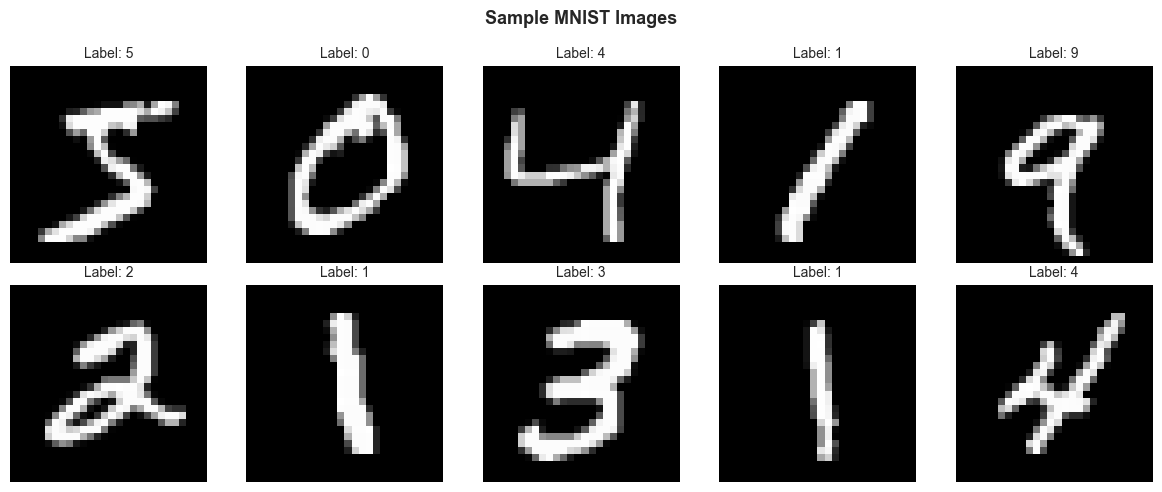

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=10)
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Build the CNN

**Architecture explanation:**

- `Conv2D(32, 3×3)` — 32 filters scan the image for low-level features (edges, curves)
- `MaxPooling2D(2×2)` — downsamples by keeping the most activated value in each 2×2 block, reducing computation while retaining the strongest signals
- `Conv2D(64, 3×3)` — 64 filters build on top of the first layer's features, detecting more complex patterns
- `Flatten` — converts the 2D feature maps into a 1D vector for the dense layers
- `Dense(64, ReLU)` — learns combinations of the extracted features
- `Dropout(0.5)` — randomly disables 50% of neurons during training to prevent overfitting
- `Dense(10, softmax)` — outputs a probability distribution over 10 digit classes

In [4]:
model = keras.Sequential([
    # First conv block
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),

    # Second conv block
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    # Classifier head
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train the Model

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)
print('Training complete.')

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8943 - loss: 0.3435 - val_accuracy: 0.9788 - val_loss: 0.0688
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9610 - loss: 0.1321 - val_accuracy: 0.9863 - val_loss: 0.0511
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9725 - loss: 0.0959 - val_accuracy: 0.9902 - val_loss: 0.0368
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9761 - loss: 0.0803 - val_accuracy: 0.9890 - val_loss: 0.0353
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9794 - loss: 0.0669 - val_accuracy: 0.9913 - val_loss: 0.0340
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9819 - loss: 0.0612 - val_accuracy: 0.9898 - val_loss: 0.0375
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9829 - loss: 0.0545 - val_accuracy: 0.9907 - val_loss: 0.0366
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9851 - loss: 0.0477 - 

## 5. Training Curves

Plotting train vs validation accuracy and loss per epoch — the gap between them shows whether the model is overfitting.

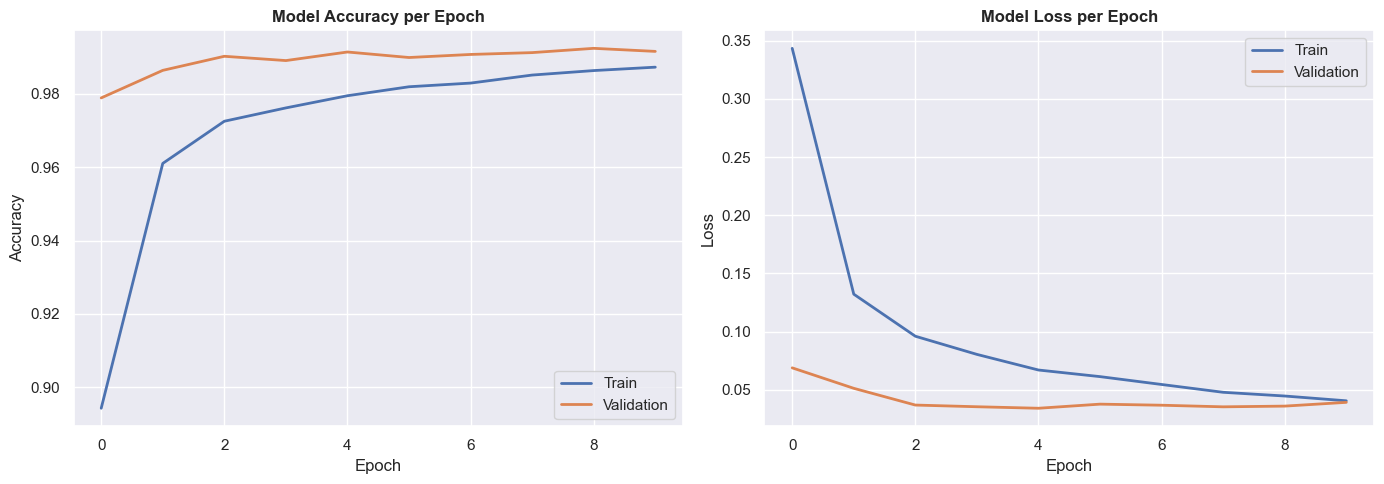

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluate on Test Set

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'CNN Test Accuracy: {test_acc:.4f}')
print(f'CNN Test Loss:     {test_loss:.4f}')
print(f'\nANN Baseline:      0.9774')
print(f'Improvement:       +{(test_acc - 0.9774)*100:.2f}%')

CNN Test Accuracy: 0.9914
CNN Test Loss:     0.0277

ANN Baseline:      0.9774
Improvement:       +1.40%


## 7. Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


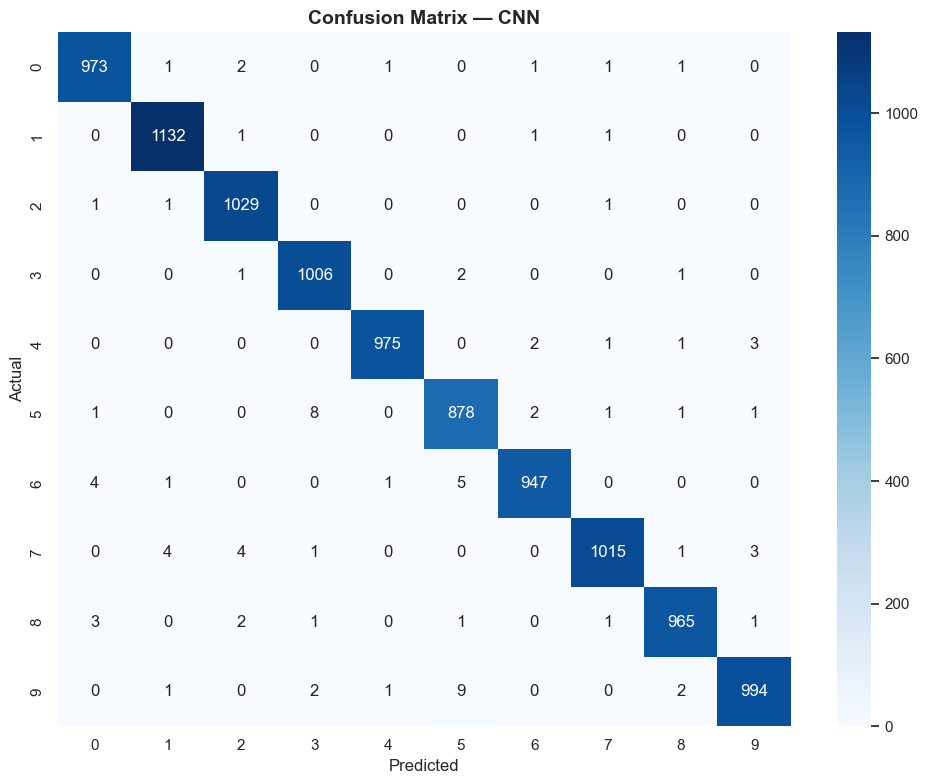

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [8]:
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — CNN', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred_labels))

## 8. Visualize Conv Layer Filters

This is what separates a real DL project from a notebook that just calls `model.fit()`. The filters in the first Conv2D layer are what the network actually learned to detect — edge detectors, curve detectors, texture patterns. Visualizing them shows the network isn't a black box.

Filter shape: (3, 3, 1, 32)


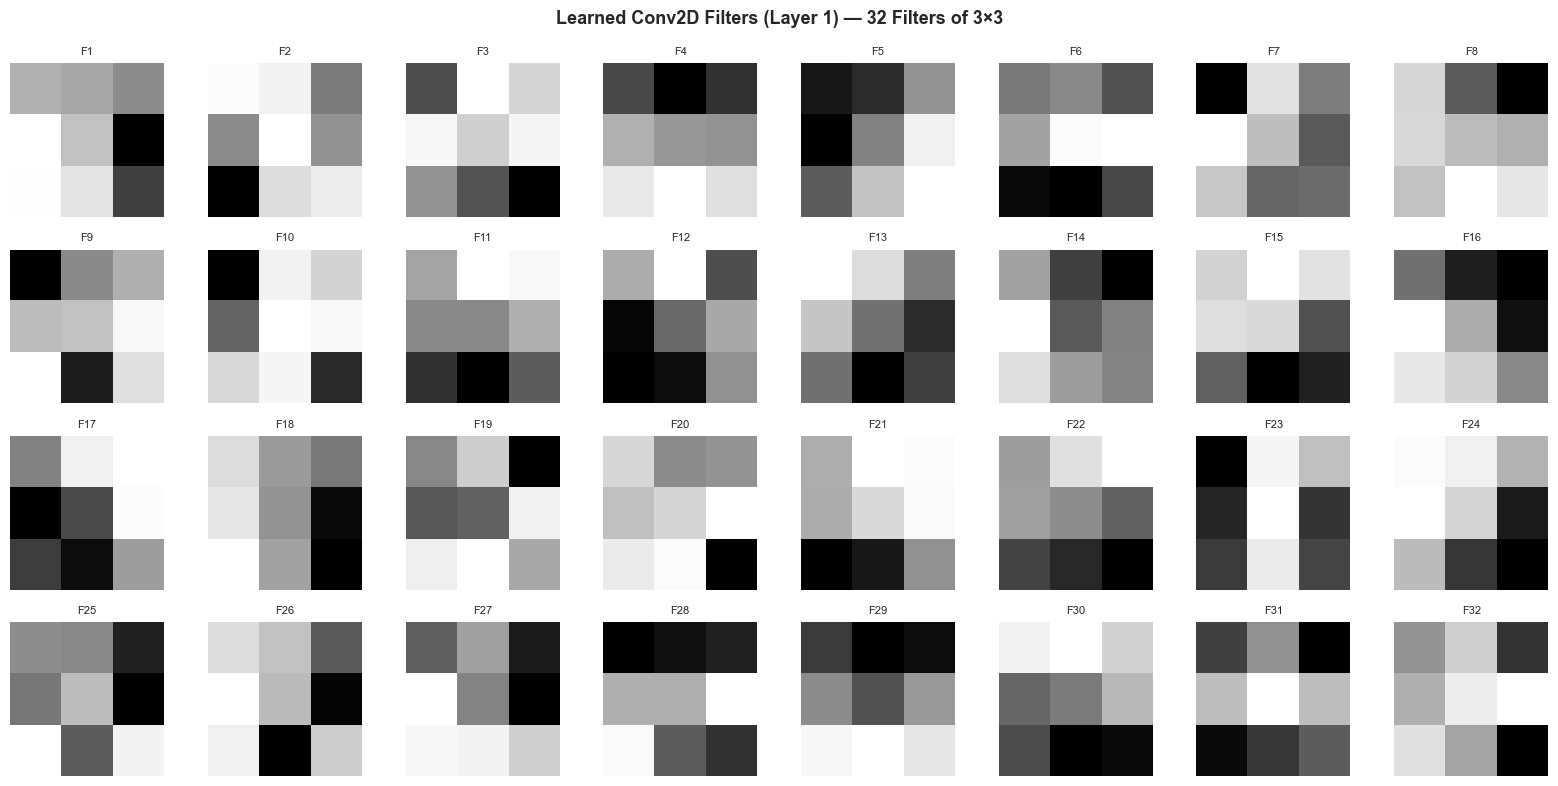

In [9]:
# Extract first conv layer weights
filters, biases = model.layers[0].get_weights()
print(f'Filter shape: {filters.shape}')  # (3, 3, 1, 32) — 32 filters of 3x3x1

# Normalize to 0-1 for visualization
f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(filters_norm[:, :, 0, i], cmap='gray')
    ax.set_title(f'F{i+1}', fontsize=8)
    ax.axis('off')

plt.suptitle('Learned Conv2D Filters (Layer 1) — 32 Filters of 3×3',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('conv_filters.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Visualize Feature Maps

Feature maps show what each filter *activates on* when it sees a real image — which parts of the digit each filter responds to. This makes the spatial learning of CNNs concrete and explainable.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


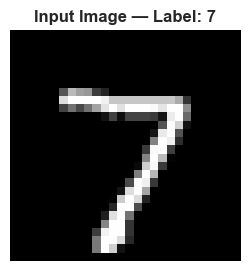

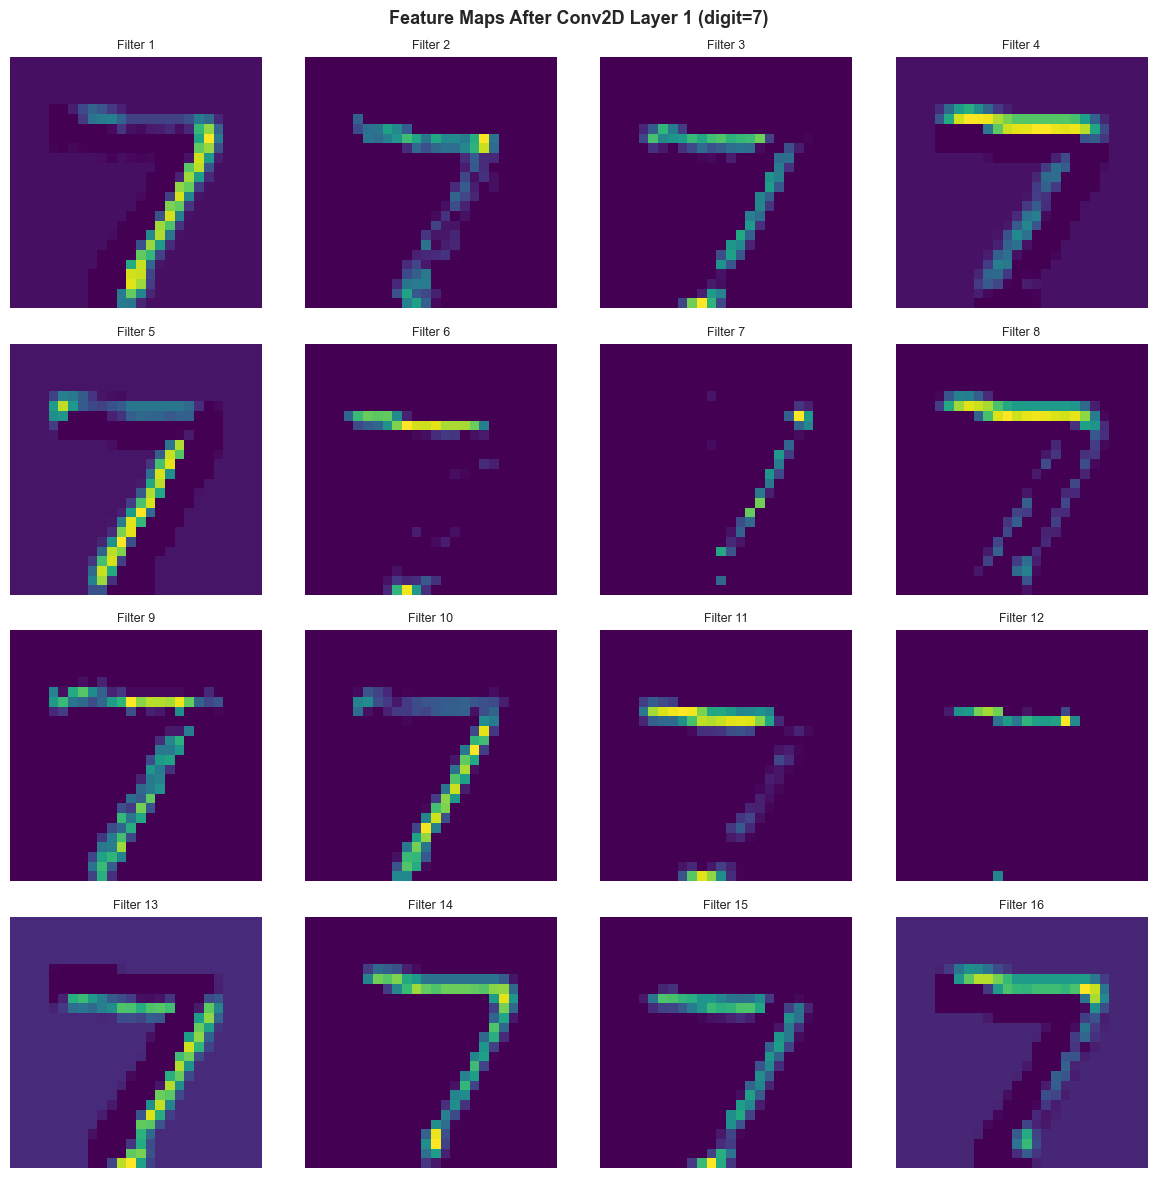

In [10]:
# Build a model that outputs after first conv layer
feature_map_model = keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

# Pick one sample image
sample = X_test[0:1]
true_label = y_test[0]
feature_maps = feature_map_model.predict(sample)

# Show original image
plt.figure(figsize=(3, 3))
plt.imshow(sample[0].reshape(28, 28), cmap='gray')
plt.title(f'Input Image — Label: {true_label}', fontweight='bold')
plt.axis('off')
plt.show()

# Show first 16 feature maps
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
    ax.set_title(f'Filter {i+1}', fontsize=9)
    ax.axis('off')

plt.suptitle(f'Feature Maps After Conv2D Layer 1 (digit={true_label})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Single Image Inference Demo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


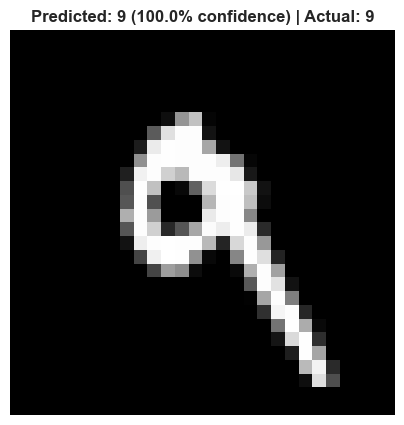

In [11]:
sample_index = 7
sample_image = X_test[sample_index]
true_label   = y_test[sample_index]

prediction     = model.predict(sample_image.reshape(1, 28, 28, 1))
predicted_label = np.argmax(prediction)
confidence      = prediction[0][predicted_label] * 100

plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f'Predicted: {predicted_label} ({confidence:.1f}% confidence) | Actual: {true_label}',
          fontweight='bold')
plt.axis('off')
plt.show()

## 11. Save the Model

In [12]:
model.save('cnn_digit_classifier.keras')
print('Model saved to cnn_digit_classifier.keras')

Model saved to cnn_digit_classifier.keras


## 12. ANN vs CNN — Final Comparison

| Model | Architecture | Test Accuracy | Parameters |
|---|---|---|---|
| ANN (`01`) | Flatten → Dense(128, ReLU) → Dropout → Dense(64, ReLU) → Dense(10, softmax) | 97.86% | ~109K |
| CNN | Conv2D(32) → Pool → Conv2D(64) → Pool → Dense(64) → Dense(10) | **99.14%** | ~93K |

**Why CNN wins:**

The ANN flattens each 28×28 image into 784 pixels and treats them as independent features — it has no concept of which pixels are neighbors. A CNN scans the image with small filters that look at local 3×3 patches, learning that an edge in the top-left of a '7' is the same pattern as an edge in the top-right of a '1'. This spatial weight sharing is why CNNs need fewer parameters to achieve higher accuracy on image data.

**Next:** `03-rnn-text-generation` — sequence modeling, where the order of inputs matters.